# Regression Results - Realized Volatility Forecasting

INFS3208 Individual Project - Distributed Market Analytics

Loads the GBTRegressor model already trained and saved by
`src/models/regression.py` (training happens there, not here - this notebook
is the visualisation/results layer, since re-running Spark ML training on
167M raw rows from inside a notebook on every edit would be slow and hard to
version control).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.append(str(Path("../src/pipeline").resolve()))
sys.path.append(str(Path("../src/models").resolve()))

from spark_session import get_spark
from regression import FEATURE_COLS, DATA_PROCESSED, MODELS_DIR, load_split, rmspe
from pyspark.ml import PipelineModel
from pyspark.sql import functions as F
from pyspark.ml.evaluation import RegressionEvaluator

spark = get_spark()
model = PipelineModel.load(str(MODELS_DIR / "regression_best"))
gbt = model.stages[-1]
print("Loaded model:", type(gbt).__name__, "| trees:", gbt.getNumTrees, "| maxDepth:", gbt.getOrDefault("maxDepth"))

26/09/21 10:10:54 WARN Utils: Your hostname, Anders-MacBook.local resolves to a loopback address: 127.0.0.1; using 130.102.160.102 instead (on interface en0)
26/09/21 10:10:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/21 10:10:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded model: GBTRegressionModel | trees: 50 | maxDepth: 5


## 1. Metrics across all three splits

Re-running the saved model's `.transform()` (fast inference, no retraining) on
train/val/test lets us display one consistent metrics table here, rather than
copy-pasting numbers out of a terminal log.

In [2]:
def evaluate_split(name):
    df = load_split(spark, name)
    pred = model.transform(df).withColumn("prediction_orig", F.exp(F.col("prediction")))
    rmse_log = RegressionEvaluator(labelCol="log_target", predictionCol="prediction", metricName="rmse").evaluate(pred)
    r2_log = RegressionEvaluator(labelCol="log_target", predictionCol="prediction", metricName="r2").evaluate(pred)
    rmspe_orig = rmspe(pred)
    return {"split": name, "rmse_log": rmse_log, "r2_log": r2_log, "rmspe_orig": rmspe_orig}, pred

rows = []
preds = {}
for split_name in ["train", "val", "test"]:
    metrics, pred_df = evaluate_split(split_name)
    rows.append(metrics)
    preds[split_name] = pred_df

metrics_table = pd.DataFrame(rows).set_index("split")
metrics_table


[Stage 17:============================================>          (90 + 4) / 112]



26/09/21 10:11:07 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/21 10:11:07 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



[Stage 19:=========>                                               (8 + 4) / 49]




[Stage 19:=================>                                      (15 + 4) / 49]




[Stage 19:===========================>                            (24 + 4) / 49]



...


[Stage 37:==================================================>     (44 + 4) / 49]




[Stage 39:============================>                           (25 + 5) / 49]




[Stage 39:=============================================>          (40 + 4) / 49]




[Stage 41:=========================================>              (36 + 4) / 49]



,rmse_log,r2_log,rmspe_orig
split,,,
train,0.256737,0.837780,0.279285
val,0.265776,0.820631,0.315962
test,0.265441,0.817758,0.282587


## 2. Predicted vs. actual - test set

The closer points sit to the y=x line, the better. Plotted on log scale since
volatility spans multiple orders of magnitude - the same absolute distance
from the line means very different things at low vs. high volatility, so a
linear-scale plot would visually hide most of the structure.


[Stage 44:====================================>                   (32 + 4) / 49]



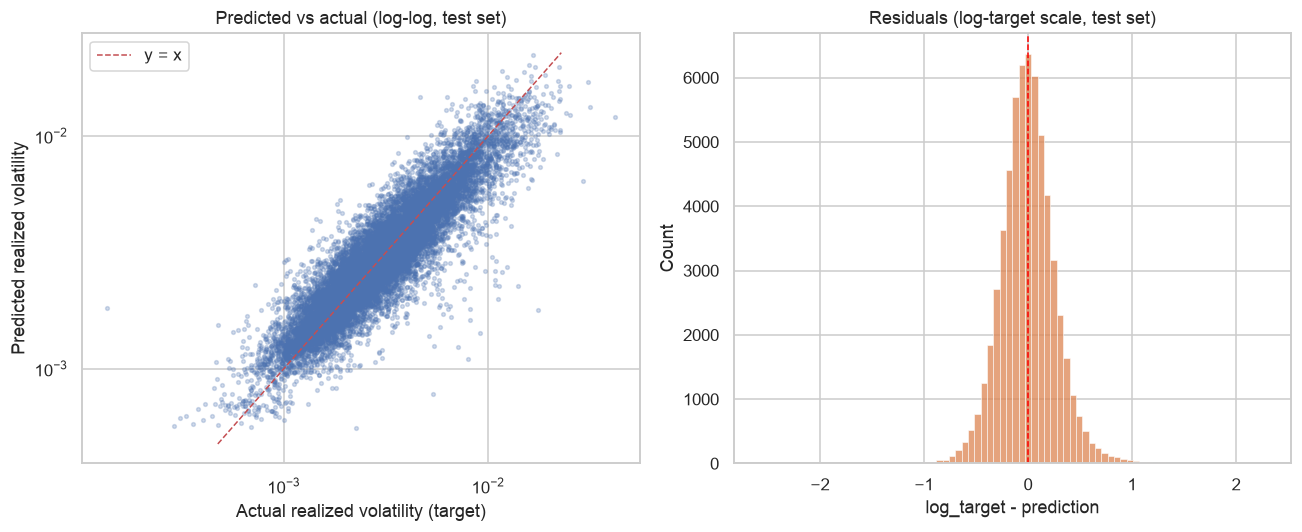

Residual mean: -0.0002525529304668933  | Residual std: 0.26544327098447246


In [3]:
test_pd = preds["test"].select("target", "prediction_orig", "log_target", "prediction").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample = test_pd.sample(n=min(15000, len(test_pd)), random_state=42)
axes[0].scatter(sample["target"], sample["prediction_orig"], s=6, alpha=0.25, color="#4C72B0")
lims = [test_pd["target"].quantile(0.001), test_pd["target"].quantile(0.999)]
axes[0].plot(lims, lims, "r--", linewidth=1, label="y = x")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Actual realized volatility (target)")
axes[0].set_ylabel("Predicted realized volatility")
axes[0].set_title("Predicted vs actual (log-log, test set)")
axes[0].legend()

resid = test_pd["log_target"] - test_pd["prediction"]
sns.histplot(resid, bins=80, ax=axes[1], color="#DD8452")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residuals (log-target scale, test set)")
axes[1].set_xlabel("log_target - prediction")

plt.tight_layout()
plt.show()

print("Residual mean:", resid.mean(), " | Residual std:", resid.std())

## 3. Feature importance

Which engineered microstructure features the GBT model actually relies on to
forecast next-window volatility.

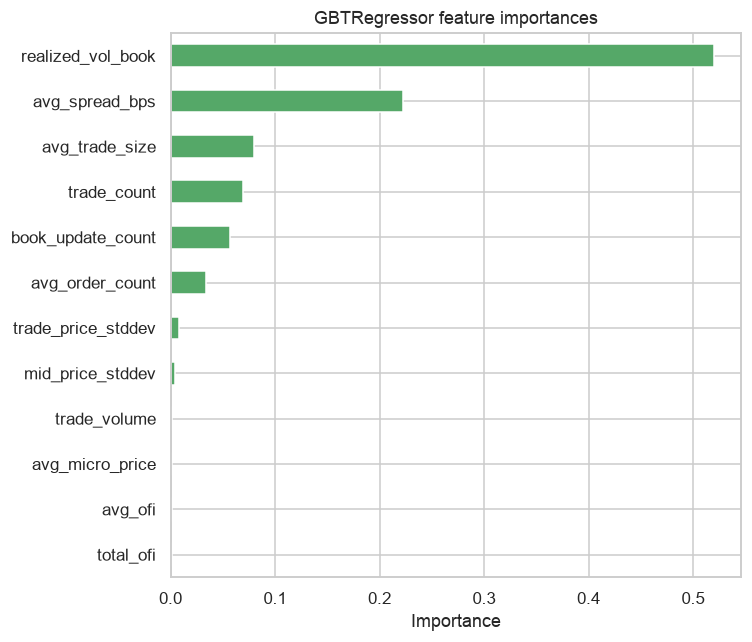

realized_vol_book     0.520267
avg_spread_bps        0.222167
avg_trade_size        0.080191
trade_count           0.069770
book_update_count     0.056560
avg_order_count       0.034018
trade_price_stddev    0.007816
mid_price_stddev      0.004004
trade_volume          0.001757
avg_micro_price       0.001272
avg_ofi               0.001139
total_ofi             0.001038
dtype: float64

In [4]:
importances = pd.Series(
    gbt.featureImportances.toArray(), index=FEATURE_COLS
).sort_values(ascending=True)

plt.figure(figsize=(7, 6))
importances.plot.barh(color="#55A868")
plt.title("GBTRegressor feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## Takeaways

- **`realized_vol_book` dominates** (~52% importance) - confirms the volatility
  clustering pattern found in the EDA (r=0.80 between current- and
  next-window volatility): past turbulence is the single strongest predictor
  of future turbulence.
- **`avg_spread_bps` is second** (~22%) - a wider spread reflects market-maker
  uncertainty, itself informative about coming volatility.
- **OFI (`total_ofi`/`avg_ofi`) contributes almost nothing here** (<0.2%
  combined) - expected, since OFI is a *directional* signal (predicts price
  movement direction), not a *volatility* signal. It should matter far more
  in the classification (trade direction) task next.
- Predicted-vs-actual points track the y=x line reasonably closely on the
  log-log plot, and residuals are centered near zero with no strong skew
  remaining - consistent with the test R²=0.82 / RMSPE≈28% reported by the
  training script.

In [5]:
spark.stop()